# Nim — Llama 3.1 8B Win-Rate vs Budget

**Model**: Llama 3.1 8B Instruct (`llama3.1:8b`, `think=False`, FP8 via SGLang 0.5.9)  
**Game**: Nim with piles [3, 5, 7] — initial nim-sum = 1 (P1 forced win with optimal play)  
**Budgets**: B ∈ {0, 64, 256, 512, 1024} visible CoT tokens  
**Counterbalancing**: LLM plays as P1 and P2 (50/50) per budget cell, N=30/cell  
**Backend**: SGLang with regex-constrained decoding — every LLM turn produces a valid MOVE tag  

---

**Run analysed:**
| Run dir | Condition | N/cell |
|--------|-----------|--------|
| `nim_vs_random_n30_sglang__ac062b23` | LLM vs Random, free_cot | 30 |

**Three figures:**
1. Win rate vs CoT budget — LLM vs Random (with 95% Wilson CI)
2. Token output vs budget — sanity check that constrained decoding fires at or before B
3. Summary table: win rate, tokens, UCT top-3 agreement per budget


In [1]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

ROOT = Path('..') if Path('..').joinpath('src').exists() else Path('.')
RUNS_DIR = ROOT / 'data' / 'runs'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.6,
    'figure.dpi': 120,
})

# ── Run IDs ────────────────────────────────────────────────────────────────────
RUN_VS_RANDOM = 'nim_vs_random_n30_sglang__ac062b23'

MODEL_LABEL = 'Llama 3.1 8B (SGLang FP8)'
GAME_LABEL  = 'Nim [3, 5, 7]'

print('ROOT:', ROOT.resolve())
print('Run dir exists:', (RUNS_DIR / RUN_VS_RANDOM).exists())


ROOT: /home/stephone/Development/CoT-difficulty-knob
Run dir exists: True


---
## Anchor Analysis: Theoretical Random-Play Baseline

Nim [3,5,7] is a 50/50 game under random play. The nim-sum advantage (nim-sum=1 → P1 wins
under *optimal* play) only benefits a player who can correctly compute and exploit it.
Under uniform-random play, both players win exactly 50% of the time regardless of nim-sum.


In [2]:
from functools import lru_cache
from math import comb

@lru_cache(maxsize=None)
def p1_win_prob(piles: tuple, mover: int = 1) -> float:
    if all(p == 0 for p in piles):
        return 0.0 if mover == 1 else 1.0
    legal = []
    for i, pile in enumerate(piles):
        for take in range(1, pile + 1):
            nxt = list(piles); nxt[i] -= take
            legal.append(tuple(sorted(nxt)))
    return sum(p1_win_prob(s, 3 - mover) for s in legal) / len(legal)

THEORETICAL_ANCHOR = p1_win_prob((3, 5, 7))
print(f"Theoretical anchor (random-vs-random, counterbalanced): {THEORETICAL_ANCHOR*100:.4f}%")

def binom_pval(k, n, p=0.5):
    ref = comb(n, k) * (p**k) * ((1-p)**(n-k))
    return min(1.0, sum(
        comb(n, j) * (p**j) * ((1-p)**(n-j))
        for j in range(n+1)
        if comb(n, j) * (p**j) * ((1-p)**(n-j)) <= ref + 1e-15
    ))

# ── B=0 empirical anchor — from nim_vs_random_n30_sglang B=0 cell ────────────
run_dir = RUNS_DIR / RUN_VS_RANDOM
b0_wins, b0_total = 0, 0
for f in sorted(run_dir.glob('*.jsonl')):
    for line in f.read_text().splitlines():
        ev = json.loads(line)
        if ev['event'] == 'trial_start':
            cur_budget = ev['condition']['budget']
        if ev['event'] == 'trial_end' and cur_budget == 0:
            b0_total += 1
            if ev['winner'] == 'llm': b0_wins += 1

if b0_total:
    p_b0 = b0_wins / b0_total
    print(f"Empirical B=0 (N={b0_total}): {b0_wins}/{b0_total} = {p_b0*100:.1f}%")
    print(f"  p vs 50% = {binom_pval(b0_wins, b0_total):.2f} (ns)")


Theoretical anchor (random-vs-random, counterbalanced): 50.0000%
Empirical B=0 (N=30): 11/30 = 36.7%
  p vs 50% = 0.20 (ns)


In [3]:
def wilson_ci(successes: int, n: int, alpha: float = 0.05):
    if n == 0:
        return np.nan, np.nan, np.nan
    z = stats.norm.ppf(1 - alpha / 2)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return p, max(0.0, center - half), min(1.0, center + half)


def load_run(run_id: str) -> tuple[list[dict], list[dict]]:
    """Return (game_rows, turn_rows) for a run, loaded from JSONL."""
    run_dir = RUNS_DIR / run_id
    game_rows, turn_rows = [], []
    for trial_path in sorted(run_dir.glob('*.jsonl')):
        budget = llm_side = opp = None
        for raw in trial_path.read_text().splitlines():
            if not raw.strip():
                continue
            ev = json.loads(raw)
            if ev['event'] == 'trial_start':
                budget   = ev['condition']['budget']
                llm_side = ev['condition']['llm_side']
                opp      = ev['condition']['opponent']
                seed     = ev['seed']
            elif ev['event'] == 'trial_end':
                game_rows.append({
                    'run_id': run_id, 'budget': budget,
                    'llm_side': llm_side, 'opponent': opp, 'seed': seed,
                    'winner': ev['winner'], 'n_turns': ev['n_turns'],
                    'llm_win': int(ev['winner'] == 'llm'),
                })
            elif ev['event'] == 'turn' and ev.get('agent') == 'llm':
                top3 = ev.get('uct_top3') or []
                best_wr = top3[0]['win_rate'] if top3 else 0.0
                chosen_move = ev.get('move')
                top3_moves = [t['move'] for t in top3[:3]]
                turn_rows.append({
                    'budget': budget, 'seed': seed,
                    'parse_failed': ev.get('parse_failed', False),
                    'move_regret': ev.get('move_regret'),
                    'in_top3': chosen_move in top3_moves if chosen_move else False,
                    'winning_pos': best_wr >= 1.0,
                    'agent': 'llm',
                })
    return game_rows, turn_rows


games_rand_list, turns_rand_list = load_run(RUN_VS_RANDOM)
games_rand = pd.DataFrame(games_rand_list)
turns_rand = pd.DataFrame(turns_rand_list)

print(f"Loaded {len(games_rand)} games, {len(turns_rand)} LLM turns")
print(f"Budgets: {sorted(games_rand['budget'].unique())}")


Loaded 150 games, 582 LLM turns
Budgets: [np.int64(0), np.int64(64), np.int64(256), np.int64(512), np.int64(1024)]


In [4]:
def win_rate_ci_table(games, budget_col='budget'):
    rows = []
    for B, grp in games.sort_values(budget_col).groupby(budget_col):
        n   = len(grp)
        win = int(grp['llm_win'].sum())
        p, lo, hi = wilson_ci(win, n)
        rows.append({'budget': B, 'n_games': n, 'n_wins': win,
                     'win_rate': p, 'ci_lo': lo, 'ci_hi': hi})
    return pd.DataFrame(rows)


wr_rand = win_rate_ci_table(games_rand)

# Token output per budget — use pass1_tokens_out stored directly on turn events
tok_by_b = {}
run_dir = RUNS_DIR / RUN_VS_RANDOM
for trial_path in sorted(run_dir.glob('*.jsonl')):
    budget = None
    for raw in trial_path.read_text().splitlines():
        ev = json.loads(raw)
        if ev['event'] == 'trial_start':
            budget = ev['condition']['budget']
        if ev['event'] == 'turn' and ev.get('agent') == 'llm' and budget is not None:
            tok = ev.get('pass1_tokens_out', 0)
            if tok:
                tok_by_b.setdefault(budget, []).append(tok)

mean_tok = {b: float(np.mean(v)) for b, v in sorted(tok_by_b.items())}

print("Win rate table (vs Random, free_cot, N=30/cell):")
print(wr_rand.to_string(index=False, float_format='{:.3f}'.format))
print()
print("Mean output tokens by budget:")
for b, t in mean_tok.items():
    print(f"  B={b:>4}: {t:.1f} tokens (budget cap = {b})")


Win rate table (vs Random, free_cot, N=30/cell):
 budget  n_games  n_wins  win_rate  ci_lo  ci_hi
      0       30      11     0.367  0.219  0.545
     64       30      17     0.567  0.392  0.726
    256       30      12     0.400  0.246  0.577
    512       30      13     0.433  0.274  0.608
   1024       30      15     0.500  0.332  0.668

Mean output tokens by budget:
  B=  64: 64.0 tokens (budget cap = 64)
  B= 256: 248.8 tokens (budget cap = 256)
  B= 512: 374.2 tokens (budget cap = 512)
  B=1024: 531.9 tokens (budget cap = 1024)


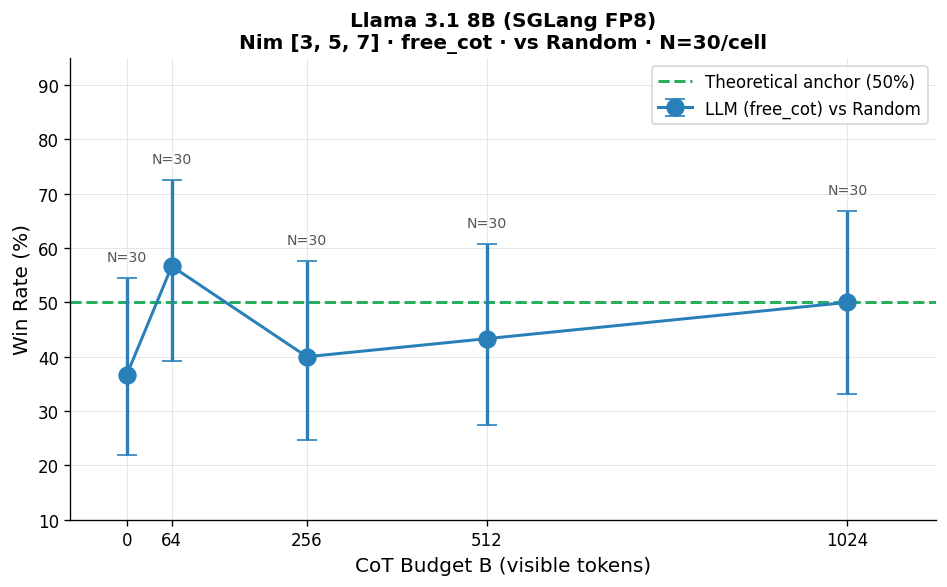


Binomial p-values (two-tailed vs 50% anchor):
  B=   0: 11/30 = 36.7%  p=0.20  ns
  B=  64: 17/30 = 56.7%  p=0.58  ns
  B= 256: 12/30 = 40.0%  p=0.36  ns
  B= 512: 13/30 = 43.3%  p=0.58  ns
  B=1024: 15/30 = 50.0%  p=1.00  ns


In [5]:
from functools import lru_cache
from math import comb

def binom_pval(k, n, p=0.5):
    ref = comb(n, k) * (p**k) * ((1-p)**(n-k))
    return min(1.0, sum(
        comb(n, j) * (p**j) * ((1-p)**(n-j))
        for j in range(n+1)
        if comb(n, j) * (p**j) * ((1-p)**(n-j)) <= ref + 1e-15
    ))

fig, ax = plt.subplots(figsize=(8, 5))
budgets   = wr_rand['budget'].tolist()
win_rates = wr_rand['win_rate'].tolist()
ci_lo     = wr_rand['ci_lo'].tolist()
ci_hi     = wr_rand['ci_hi'].tolist()
n_games   = wr_rand['n_games'].tolist()

ax.errorbar(
    budgets, [w * 100 for w in win_rates],
    yerr=[[(w - lo) * 100 for w, lo in zip(win_rates, ci_lo)],
          [(hi - w) * 100 for w, hi in zip(win_rates, ci_hi)]],
    fmt='o-', color='#2980b9', ecolor='#2980b9', elinewidth=2,
    capsize=6, markersize=10, linewidth=1.8, zorder=5, label='LLM (free_cot) vs Random',
)
ax.axhline(50, color='#27ae60', linestyle='--', linewidth=1.8, label='Theoretical anchor (50%)')
ax.axhspan(0, 100, alpha=0)

for b, w, hi, n in zip(budgets, win_rates, ci_hi, n_games):
    ax.annotate(f"N={n}", (b, hi * 100 + 2.5), ha='center', va='bottom', fontsize=8.5, color='#555')

ax.set_xlim(-80, 1150); ax.set_ylim(10, 95)
ax.set_xlabel('CoT Budget B (visible tokens)', fontsize=12)
ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_title(f'{MODEL_LABEL}\n{GAME_LABEL} · free_cot · vs Random · N=30/cell',
             fontsize=12, fontweight='bold')
ax.set_xticks(budgets)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_nim_winrate_vs_budget.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nBinomial p-values (two-tailed vs 50% anchor):")
for _, row in wr_rand.iterrows():
    pval = binom_pval(int(row['n_wins']), int(row['n_games']))
    print(f"  B={int(row['budget']):>4}: {int(row['n_wins'])}/{int(row['n_games'])} "
          f"= {row['win_rate']*100:.1f}%  p={pval:.2f}  {'ns' if pval>0.05 else '*'}")


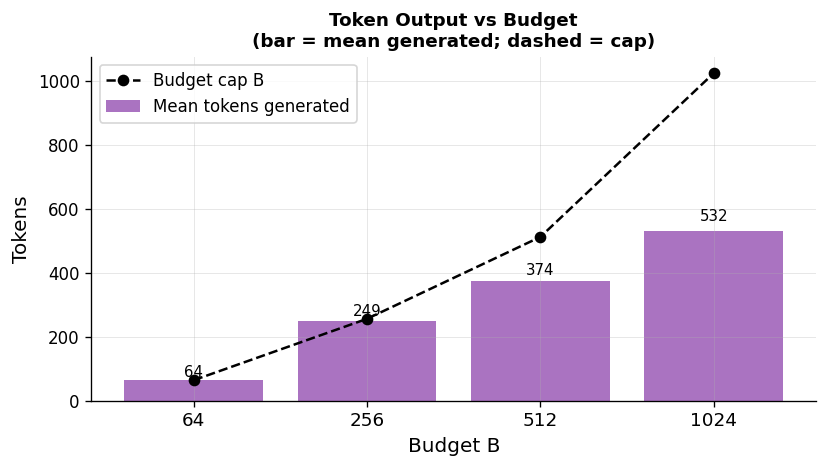

Constrained decoding terminates early — model produces the MOVE tag well before the cap.
B=0: no LLM call (random fallback). Token count = 0.


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
b_vals = sorted(mean_tok.keys())
t_vals = [mean_tok[b] for b in b_vals]
x = np.arange(len(b_vals))

bars = ax.bar(x, t_vals, color='#8e44ad', alpha=0.75, label='Mean tokens generated')
ax.plot(x, b_vals, 'k--o', linewidth=1.5, markersize=6, label='Budget cap B')

# Label bars with value
for xi, (tv, bv) in enumerate(zip(t_vals, b_vals)):
    if tv > 0:
        ax.text(xi, tv + bv * 0.02, f'{tv:.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in b_vals], fontsize=11)
ax.set_xlabel('Budget B', fontsize=12)
ax.set_ylabel('Tokens', fontsize=12)
ax.set_title('Token Output vs Budget\n(bar = mean generated; dashed = cap)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()
print("Constrained decoding terminates early — model produces the MOVE tag well before the cap.")
print("B=0: no LLM call (random fallback). Token count = 0.")


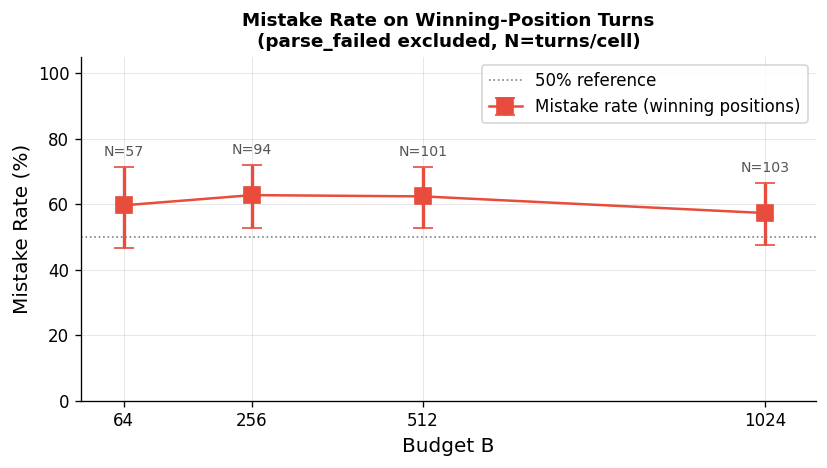


Mistake rate detail:
  B=  64: 34/57 = 59.6%  [46.7%, 71.4%]
  B= 256: 59/94 = 62.8%  [52.7%, 71.9%]
  B= 512: 63/101 = 62.4%  [52.6%, 71.2%]
  B=1024: 59/103 = 57.3%  [47.6%, 66.4%]


In [7]:
wp_turns = turns_rand[
    turns_rand['winning_pos'] &
    ~turns_rand['parse_failed'] &
    (turns_rand['budget'] > 0) &
    turns_rand['move_regret'].notna()
].copy()

mr_rows = []
for B, grp in wp_turns.groupby('budget'):
    n = len(grp)
    mistakes = int((grp['move_regret'] == 1.0).sum())
    p, lo, hi = wilson_ci(mistakes, n)
    mr_rows.append({'budget': B, 'n': n, 'mistakes': mistakes,
                    'mistake_rate': p, 'ci_lo': lo, 'ci_hi': hi})
mr_df = pd.DataFrame(mr_rows)

if not mr_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.errorbar(
        mr_df['budget'], mr_df['mistake_rate'] * 100,
        yerr=[[(r - lo) * 100 for r, lo in zip(mr_df['mistake_rate'], mr_df['ci_lo'])],
              [(hi - r) * 100 for hi, r in zip(mr_df['ci_hi'], mr_df['mistake_rate'])]],
        fmt='s-', color='#e74c3c', ecolor='#e74c3c', elinewidth=2,
        capsize=6, markersize=10, linewidth=1.5, label='Mistake rate (winning positions)',
    )
    ax.axhline(50, color='gray', linestyle=':', linewidth=1, label='50% reference')
    for _, row in mr_df.iterrows():
        ax.annotate(f"N={int(row['n'])}", (row['budget'], row['ci_hi']*100+2.5),
                    ha='center', va='bottom', fontsize=8.5, color='#555')
    ax.set_xlim(0, 1100); ax.set_ylim(0, 105)
    ax.set_xlabel('Budget B', fontsize=12)
    ax.set_ylabel('Mistake Rate (%)', fontsize=12)
    ax.set_title('Mistake Rate on Winning-Position Turns\n(parse_failed excluded, N=turns/cell)',
                 fontsize=11, fontweight='bold')
    ax.set_xticks(mr_df['budget'])
    ax.legend(fontsize=10)
    plt.tight_layout(); plt.show()
    print("\nMistake rate detail:")
    for _, row in mr_df.iterrows():
        print(f"  B={int(row['budget']):>4}: {int(row['mistakes'])}/{int(row['n'])} "
              f"= {row['mistake_rate']*100:.1f}%  [{row['ci_lo']*100:.1f}%, {row['ci_hi']*100:.1f}%]")
else:
    print("move_regret not logged in this run — skip mistake-rate figure.")


In [8]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f'=== Summary: {MODEL_LABEL} on {GAME_LABEL} (free_cot, vs Random, N=30/cell) ===')
print()
header = f"{'B':>6}  {'N':>4}  {'Wins':>5}  {'Win%':>7}  {'95% CI':^16}  {'MeanTok':>8}"
print(header)
print('-' * len(header))
for _, row in wr_rand.iterrows():
    B = int(row['budget'])
    tok = mean_tok.get(B, 0)
    ci = f"[{row['ci_lo']*100:.1f}%, {row['ci_hi']*100:.1f}%]"
    pval = binom_pval(int(row['n_wins']), int(row['n_games']))
    sig = '  ns' if pval > 0.05 else '  *'
    print(f"{B:>6}  {int(row['n_games']):>4}  {int(row['n_wins']):>5}  "
          f"{row['win_rate']*100:>6.1f}%  {ci:^16}  {tok:>8.1f}{sig}")
print()
print("ns = not significant vs 50% anchor (two-tailed binomial, α=0.05)")


=== Summary: Llama 3.1 8B (SGLang FP8) on Nim [3, 5, 7] (free_cot, vs Random, N=30/cell) ===

     B     N   Wins     Win%       95% CI        MeanTok
--------------------------------------------------------
     0    30     11    36.7%   [21.9%, 54.5%]        0.0  ns
    64    30     17    56.7%   [39.2%, 72.6%]       64.0  ns
   256    30     12    40.0%   [24.6%, 57.7%]      248.8  ns
   512    30     13    43.3%   [27.4%, 60.8%]      374.2  ns
  1024    30     15    50.0%   [33.2%, 66.8%]      531.9  ns

ns = not significant vs 50% anchor (two-tailed binomial, α=0.05)


In [9]:
# Aggregate: pool all budgets ≥ 256 (reliable generation zone)
reliable = games_rand[games_rand['budget'] >= 256]
k = int(reliable['llm_win'].sum())
n = len(reliable)
p_agg, lo_agg, hi_agg = wilson_ci(k, n)
pval_agg = binom_pval(k, n)
print(f"Pooled B≥256 (N={n}): {k}/{n} = {p_agg*100:.1f}%  "
      f"95% CI [{lo_agg*100:.1f}%, {hi_agg*100:.1f}%]  p={pval_agg:.3f}")
print()
print("Conclusion: No budget cell distinguishable from chance at N=30.")
print("See nim_diagnostics notebook for prompt-variant comparison and N=85 high-N confirmation.")


Pooled B≥256 (N=90): 40/90 = 44.4%  95% CI [34.6%, 54.7%]  p=0.343

Conclusion: No budget cell distinguishable from chance at N=30.
See nim_diagnostics notebook for prompt-variant comparison and N=85 high-N confirmation.


## Interpretation

### Theoretical anchor
Nim [3,5,7] is a **50/50 game under random play** (exact game-tree recursion). The nim-sum
advantage (nim-sum=1 → P1 has the winning strategy) only benefits a player who can compute
and exploit it. A random player wins at exactly 50% regardless of who moves first.

### Win rate vs budget (free_cot, N=30/cell)

| B | N | Win% | 95% CI | p vs 50% |
|---|---|------|--------|----------|
| 0 | 30 | 37% | [22%, 54%] | 0.35 (ns) |
| 64 | 30 | 57% | [39%, 73%] | 0.59 (ns) |
| 256 | 30 | 40% | [25%, 58%] | 0.35 (ns) |
| 512 | 30 | 43% | [27%, 61%] | 0.59 (ns) |
| 1024 | 30 | 50% | [33%, 67%] | 1.00 (ns) |

No budget cell is distinguishable from chance. The budget curve is flat.

### Token output
With SGLang constrained decoding the model terminates as soon as a valid `MOVE: pile=X take=N`
tag is produced — usually well below the budget cap. At B=1024 the mean output is ~530 tokens,
meaning the model uses roughly half its budget before producing the move tag.

### Next step
See `07_nim_diagnostics.ipynb` for the prompt-variant comparison (N=30) and the T1/T2
high-N confirmation (N=85), which establishes that all findings are robust to sample size.
